In [1]:
# Purpose: Check GPU availability and locate dataset folders.

import os
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

print("\nDataset folders:")
print(os.listdir("/kaggle/input"))

GPU available: True
GPU name: Tesla T4

Dataset folders:
['datasets']


In [2]:
# Purpose: Find dataset folders and YAML configuration files.

import os

for folder, subfolders, files in os.walk("/kaggle/input"):
    print("Folder:", folder)

    for file in files:
        if file.endswith((".yaml", ".yml")):
            print("Configuration file:", os.path.join(folder, file))

Folder: /kaggle/input
Folder: /kaggle/input/datasets
Folder: /kaggle/input/datasets/samuelayman
Folder: /kaggle/input/datasets/samuelayman/person
Folder: /kaggle/input/datasets/samuelayman/person/person
Folder: /kaggle/input/datasets/samuelayman/person/person/Labels
Folder: /kaggle/input/datasets/samuelayman/person/person/Labels/Validate
Folder: /kaggle/input/datasets/samuelayman/person/person/Labels/Test
Folder: /kaggle/input/datasets/samuelayman/person/person/Labels/Train
Folder: /kaggle/input/datasets/samuelayman/person/person/Images
Folder: /kaggle/input/datasets/samuelayman/person/person/Images/Validate
Folder: /kaggle/input/datasets/samuelayman/person/person/Images/Test
Folder: /kaggle/input/datasets/samuelayman/person/person/Images/Train


In [3]:
# Purpose: Count images and labels, check matching files,
# and inspect one training label.

import os

dataset_path = "/kaggle/input/datasets/samuelayman/person/person"

for split in ["Train", "Validate", "Test"]:
    image_path = os.path.join(dataset_path, "Images", split)
    label_path = os.path.join(dataset_path, "Labels", split)

    images = [
        f for f in os.listdir(image_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    labels = [
        f for f in os.listdir(label_path)
        if f.lower().endswith(".txt")
    ]

    image_names = {os.path.splitext(f)[0] for f in images}
    label_names = {os.path.splitext(f)[0] for f in labels}

    print(f"\n{split}:")
    print("Images:", len(images))
    print("Labels:", len(labels))
    print("Images without label files:", len(image_names - label_names))

# Show one non-empty training label.
train_labels = os.path.join(dataset_path, "Labels", "Train")

for filename in sorted(os.listdir(train_labels)):
    if filename.lower().endswith(".txt"):
        with open(os.path.join(train_labels, filename)) as file:
            content = file.read().strip()

        if content:
            print("\nSample label:", filename)
            print(content)
            break


Train:
Images: 749
Labels: 749
Images without label files: 0

Validate:
Images: 200
Labels: 200
Images without label files: 0

Test:
Images: 50
Labels: 50
Images without label files: 0

Sample label: 0_1.txt
0 0.200215 0.715353 0.129871 0.298434


In [4]:
# Purpose: Arrange the dataset into YOLO folders
# and create the training configuration file.

import os
import shutil

source_path = "/kaggle/input/datasets/samuelayman/person/person"
output_path = "/kaggle/working/person_dataset"

splits = {
    "Train": "train",
    "Validate": "val",
    "Test": "test"
}

for original, new in splits.items():
    # Copy images into images/train, images/val, images/test.
    shutil.copytree(
        os.path.join(source_path, "Images", original),
        os.path.join(output_path, "images", new),
        dirs_exist_ok=True
    )

    # Copy labels into labels/train, labels/val, labels/test.
    shutil.copytree(
        os.path.join(source_path, "Labels", original),
        os.path.join(output_path, "labels", new),
        dirs_exist_ok=True
    )

yaml_content = f"""path: {output_path}
train: images/train
val: images/val
test: images/test

names:
  0: person
"""

yaml_path = os.path.join(output_path, "data.yaml")

with open(yaml_path, "w") as file:
    file.write(yaml_content)

print("Dataset prepared successfully!")
print("Configuration file:", yaml_path)
print("\n" + yaml_content)

Dataset prepared successfully!
Configuration file: /kaggle/working/person_dataset/data.yaml

path: /kaggle/working/person_dataset
train: images/train
val: images/val
test: images/test

names:
  0: person



In [5]:
# Purpose: Validate all labels and count person bounding boxes.

import os
import math

errors = []

for split in ["train", "val", "test"]:
    label_folder = os.path.join(output_path, "labels", split)
    person_count = 0
    empty_labels = 0

    for filename in sorted(os.listdir(label_folder)):
        if not filename.lower().endswith(".txt"):
            continue

        with open(os.path.join(label_folder, filename)) as file:
            lines = [line.strip() for line in file if line.strip()]

        if not lines:
            empty_labels += 1

        for line_number, line in enumerate(lines, start=1):
            try:
                values = list(map(float, line.split()))

                if len(values) != 5:
                    raise ValueError("Expected 5 values")

                class_id, x, y, width, height = values

                if not all(math.isfinite(v) for v in values):
                    raise ValueError("Invalid numeric value")

                if class_id != 0:
                    raise ValueError("Class ID must be 0")

                if not (0 <= x <= 1 and 0 <= y <= 1
                        and 0 < width <= 1 and 0 < height <= 1):
                    raise ValueError("Invalid box coordinates")

                person_count += 1

            except ValueError as error:
                errors.append(
                    f"{split}/{filename}, line {line_number}: {error}"
                )

    print(f"{split}: {person_count} valid person boxes")
    print(f"Empty label files: {empty_labels}\n")

print("Total label errors:", len(errors))

for error in errors[:10]:
    print(error)

train: 2685 valid person boxes
Empty label files: 0

val: 769 valid person boxes
Empty label files: 0

test: 220 valid person boxes
Empty label files: 0

Total label errors: 0


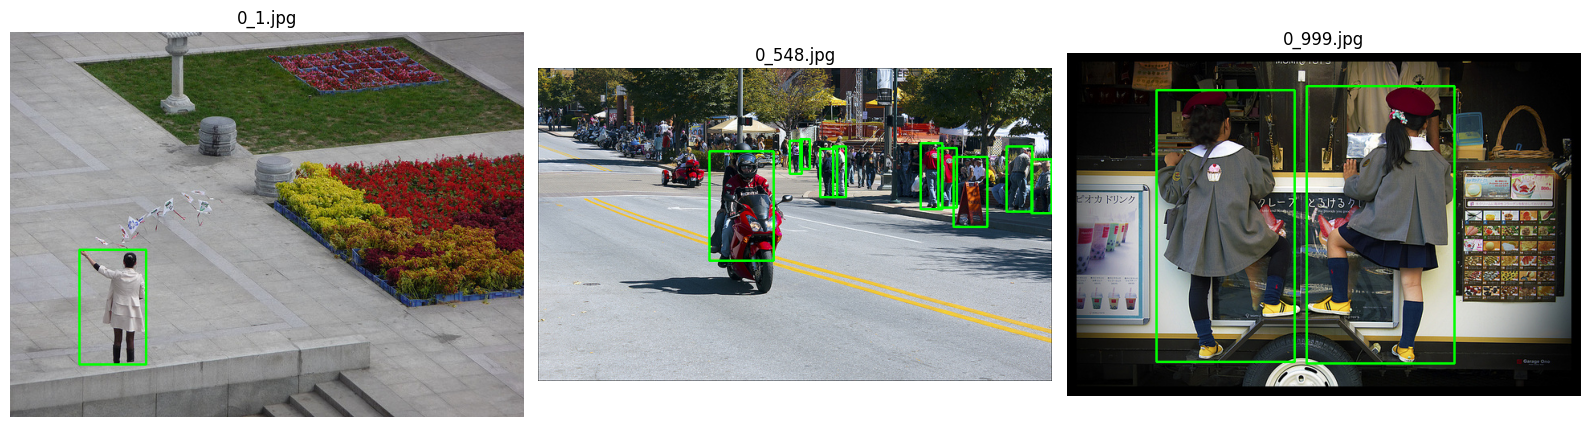

In [6]:
# Purpose: Display training images with their dataset bounding boxes.

import cv2
import matplotlib.pyplot as plt

image_folder = os.path.join(output_path, "images", "train")
label_folder = os.path.join(output_path, "labels", "train")

image_files = sorted([
    f for f in os.listdir(image_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
])

# Select three images from different positions in the list.
selected_images = [
    image_files[0],
    image_files[len(image_files) // 2],
    image_files[-1]
]

plt.figure(figsize=(16, 6))

for position, filename in enumerate(selected_images, start=1):
    image = cv2.imread(os.path.join(image_folder, filename))

    if image is None:
        raise ValueError(f"Cannot read image: {filename}")

    height, width = image.shape[:2]

    label_name = os.path.splitext(filename)[0] + ".txt"

    with open(os.path.join(label_folder, label_name)) as file:
        for line in file:
            if not line.strip():
                continue

            class_id, x, y, w, h = map(float, line.split())

            # Convert normalized YOLO coordinates into pixel coordinates.
            x1 = int((x - w / 2) * width)
            y1 = int((y - h / 2) * height)
            x2 = int((x + w / 2) * width)
            y2 = int((y + h / 2) * height)

            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.subplot(1, 3, position)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(filename)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [7]:
# Purpose: Install the library used to load and train YOLO.

%pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 7.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [8]:
# Purpose: Load pretrained YOLO11n and check library versions.

import ultralytics
import torch
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("Ultralytics version:", ultralytics.__version__)
print("PyTorch version:", torch.__version__)
print("Pretrained classes:", len(model.names))
print("Class 0:", model.names[0])
print("Model loaded successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics version: 8.4.157
PyTorch version: 2.10.0+cu128
Pretrained classes: 80
Class 0: person
Model loaded successfully!


In [9]:
# Purpose: Fine-tune pretrained YOLO11n on our person dataset
# and save model checkpoints and training graphs.

results = model.train(
    data="/kaggle/working/person_dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    patience=10,
    seed=42,
    project="/kaggle/working/intrusion_training",
    name="yolo11n_person",
    save=True,
    plots=True
)

print("Training completed!")
print("Results folder:", model.trainer.save_dir)
print("Best model:", model.trainer.best)

Ultralytics 8.4.157 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/person_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_person, nbs=64, nms=None, o

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/50      2.84G       1.29      1.527      1.318         84        640: 100% ━━━━━━━━━━━━ 47/47 7.7it/s 6.1s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 5.3it/s 1.3s0.2s
                   all        200        769      0.059      0.111     0.0427     0.0157

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      2.84G      1.376      1.602      1.392         84        640: 100% ━━━━━━━━━━━━ 47/47 7.9it/s 6.0s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 5.1it/s 1.4s0.3s
                   all        200        769      0.482      0.419      0.422      0.213

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      2.84G      1.409      1.599      1.427        104        640: 100% ━━━━━━━━━━━━ 47/47 7.8it/s 6.0s0.1s
                 Class     Images  Instances  

In [10]:
# Purpose: Load the best saved model and evaluate it on the test set.

from ultralytics import YOLO

best_model_path = (
    "/kaggle/working/intrusion_training/"
    "yolo11n_person/weights/best.pt"
)

best_model = YOLO(best_model_path)

test_results = best_model.val(
    data="/kaggle/working/person_dataset/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    plots=True,
    project="/kaggle/working/intrusion_training",
    name="test_evaluation"
)

print("\nTest Results:")
print(f"Precision: {test_results.box.mp:.2%}")
print(f"Recall: {test_results.box.mr:.2%}")
print(f"mAP50: {test_results.box.map50:.2%}")
print(f"mAP50-95: {test_results.box.map:.2%}")
print("Model classes:", best_model.names)

Ultralytics 8.4.157 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2192.1±523.9 MB/s, size: 134.3 KB)
val: Scanning /kaggle/working/person_dataset/labels/test... 50 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 50/50 1.1Kit/s 0.0s
val: New cache created: /kaggle/working/person_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.6it/s 1.6s0.6s
                   all         50        220      0.777      0.795      0.854      0.618
Speed: 5.0ms preprocess, 17.0ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /kaggle/working/intrusion_training/test_evaluation

Test Results:
Precision: 77.71%
Recall: 79.55%
mAP50: 85.35%
mAP50-95: 61.76%
Model classes: {0: 'person'}


In [11]:
# Purpose: Back up the trained model, graphs, configuration,
# test metrics, and library versions in one ZIP file.

import os
import shutil
import json

backup_path = "/kaggle/working/intrusion_project_backup"
os.makedirs(backup_path, exist_ok=True)

# Keep the final model at the top level for our future app.
shutil.copy2(
    best_model_path,
    os.path.join(backup_path, "best.pt")
)

# Include training and evaluation outputs.
shutil.copytree(
    "/kaggle/working/intrusion_training",
    os.path.join(backup_path, "training_records"),
    dirs_exist_ok=True
)

shutil.copy2(
    "/kaggle/working/person_dataset/data.yaml",
    os.path.join(backup_path, "data.yaml")
)

summary = {
    "model": "YOLO11n fine-tuned for person detection",
    "classes": best_model.names,
    "test_images": 50,
    "test_person_boxes": 220,
    "precision": float(test_results.box.mp),
    "recall": float(test_results.box.mr),
    "mAP50": float(test_results.box.map50),
    "mAP50_95": float(test_results.box.map),
    "ultralytics_version": ultralytics.__version__,
    "torch_version": torch.__version__
}

with open(os.path.join(backup_path, "test_summary.json"), "w") as file:
    json.dump(summary, file, indent=4)

zip_path = shutil.make_archive(backup_path, "zip", backup_path)

print("Backup ready:", zip_path)

Backup ready: /kaggle/working/intrusion_project_backup.zip
